## **DAY 5 — Exploratory Data Analysis (EDA) + Data Storytelling**

<br>
<br>

### **What is EDA?**

**Exploratory Data Analysis (EDA)** is the process of exploring data before building Machine Learning models. Think of it as 'getting to know' your data to ensure it is clean, consistent, and ready for modeling.

#### **The EDA Workflow**
1. **Understand Dataset**: Check dimensions, column names, and data types.
2. **Check Missing Values**: Identify gaps in the data that need to be filled or removed.
3. **Study Distributions**: See how variables are spread out (e.g., histograms).
4. **Analyze Relationships**: Look for correlations between different features.
5. **Detect Outliers**: Find unusual data points that might skew results.
6. **Generate Insights**: Formulate conclusions based on the visuals and statistics.
7. **Prepare for ML**: Finalize data cleaning and feature engineering based on findings.

<br>
<br>

## **PART 2: LOAD DATASET**

In [ ]:
import pandas as pd

data = {
    "Age": [22,25,30,35,40,28,32],
    "Salary": [25000,30000,45000,60000,80000,40000,50000],
    "Experience": [1,2,5,8,12,4,6],
    "Department": [
        "IT","HR","IT",
        "Finance","Finance",
        "HR","IT"
    ]
}

df = pd.DataFrame(data)

<br>
<br>

## **PART 3 — Basic Dataset Understanding**

In [ ]:
# 1. head() - View the first few rows
print("First 5 rows:")
display(df.head(5))

# 2. shape - Check rows and columns
print(f"\nDataset Shape (Rows, Columns): {df.shape}")

# 3. info() - Check data types and non-null counts
print("\nDataset Information:")
df.info()

# 4. describe() - Statistical summary
print("\nStatistical Summary:")
display(df.describe())

First 5 rows:


,Age,Salary,Experience,Department
0,22,25000,1,IT
1,25,30000,2,HR
2,30,45000,5,IT
3,35,60000,8,Finance
4,40,80000,12,Finance



Dataset Shape (Rows, Columns): (7, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Age         7 non-null      int64 
 1   Salary      7 non-null      int64 
 2   Experience  7 non-null      int64 
 3   Department  7 non-null      object
dtypes: int64(3), object(1)
memory usage: 356.0+ bytes

Statistical Summary:


,Age,Salary,Experience
count,7.000000,7.000000,7.000000
mean,30.285714,47142.857143,5.428571
std,6.074929,18676.443018,3.735289
min,22.000000,25000.000000,1.000000
25%,26.500000,35000.000000,3.000000
50%,30.000000,45000.000000,5.000000
75%,33.500000,55000.000000,7.000000
max,40.000000,80000.000000,12.000000


<br>
<br>

## **PART 4 — Univariate Analysis**

Analyzing **ONE** variable at a time.

### **Numerical Column Analysis**

In [ ]:
# Mean
print(f"Mean Salary: {df['Salary'].mean()}")

# Median
print(f"Median Salary: {df['Salary'].median()}")

# Standard Deviation
print(f"Salary Standard Deviation: {df['Salary'].std()}")

Mean Salary: 47142.857142857145
Median Salary: 45000.0
Salary Standard Deviation: 18676.44301813179


### **Distribution Visualization**

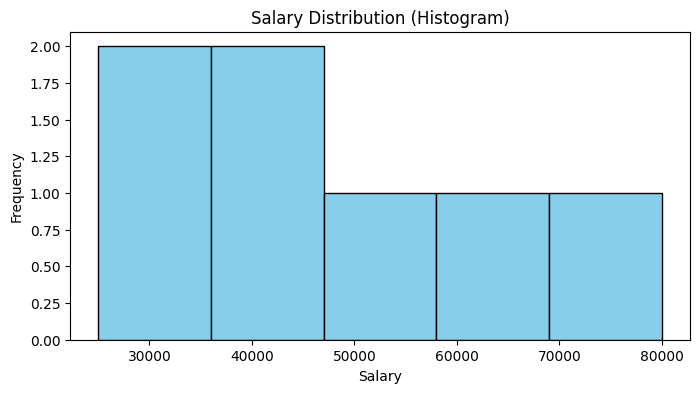

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(8, 4))
plt.hist(df["Salary"], bins=5, color='skyblue', edgecolor='black')
plt.title("Salary Distribution (Histogram)")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

**Boxplot**

Used for:
- Outlier detection
- Spread analysis

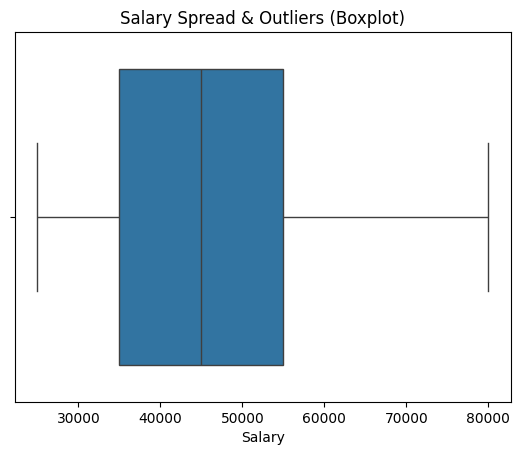

In [ ]:
sns.boxplot(x=df["Salary"])
plt.title("Salary Spread & Outliers (Boxplot)")
plt.show()

### **Categorical Analysis**

**value_counts()**
This shows the frequency of each unique category.

Department Frequency:
Department
IT         3
HR         2
Finance    2
Name: count, dtype: int64


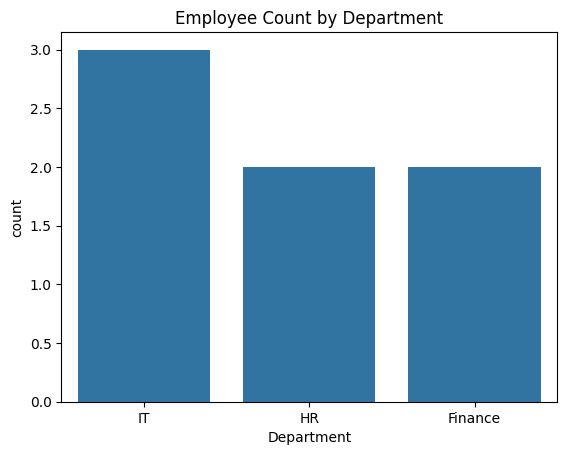

In [ ]:
print("Department Frequency:")
print(df["Department"].value_counts())

# Countplot
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=df["Department"])
plt.title("Employee Count by Department")
plt.show()

### **Categorical Analysis**

**value_counts()**
This shows the frequency of each unique category.

Department Frequency:
Department
IT         3
HR         2
Finance    2
Name: count, dtype: int64


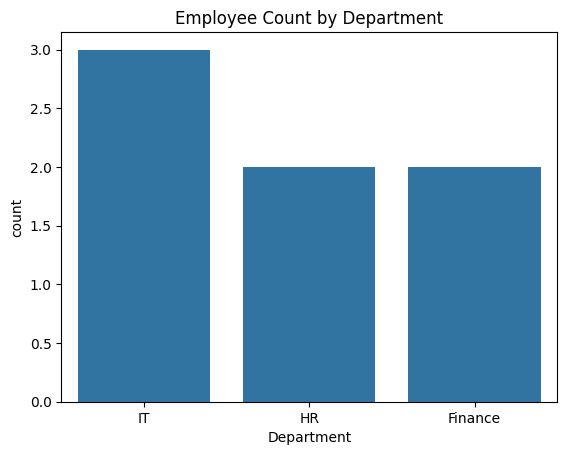

In [ ]:
print("Department Frequency:")
print(df["Department"].value_counts())

# Countplot
sns.countplot(x=df["Department"])
plt.title("Employee Count by Department")
plt.show()

<br>
<br>

## **PART 5 — Bivariate Analysis**

Analyzing the relationship between **TWO** variables.

### **Salary vs Experience**

**Scatter Plot**
We use a scatter plot to see if there is a visual trend between years of experience and salary.

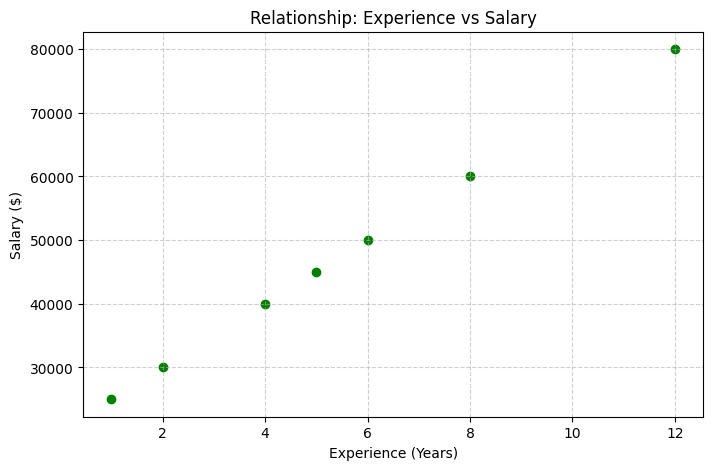

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["Experience"], df["Salary"], color='green')

plt.title("Relationship: Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight Example**

You may observe:
👉 **More experience → Higher salary**

This indicates a **positive correlation** between these two variables.

### **Correlation**

Correlation measures the strength and direction of the linear relationship between two variables.

**Correlation Matrix**

<br>
<br>

In [ ]:
# Calculate the correlation matrix for numerical columns
corr = df.corr(numeric_only=True)

print("Correlation Matrix:")
display(corr)

Correlation Matrix:


,Age,Salary,Experience
Age,1.000000,0.992605,0.992605
Salary,0.992605,1.000000,1.000000
Experience,0.992605,1.000000,1.000000


**Heatmap Visualization**

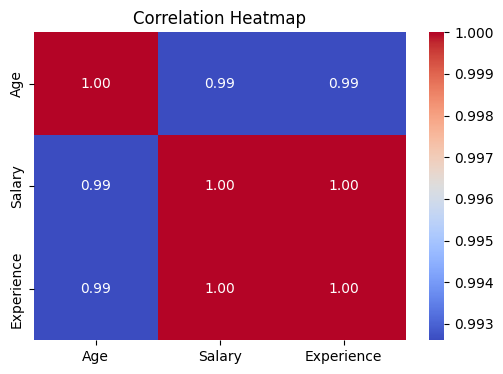

In [ ]:
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### **Correlation Interpretation**

| Value | Meaning |
| :--- | :--- |
| **+1** | Strong positive relationship |
| **0** | No linear relationship |
| **-1** | Strong negative relationship |

## **PART 6 — Multivariate Analysis**

Analyzing **MORE** than 2 variables simultaneously.

### **Pairplot**

A **Pairplot** shows the relationship between every combination of numerical variables in the dataset. It's a powerful tool for spotting patterns across the entire dataframe at once.

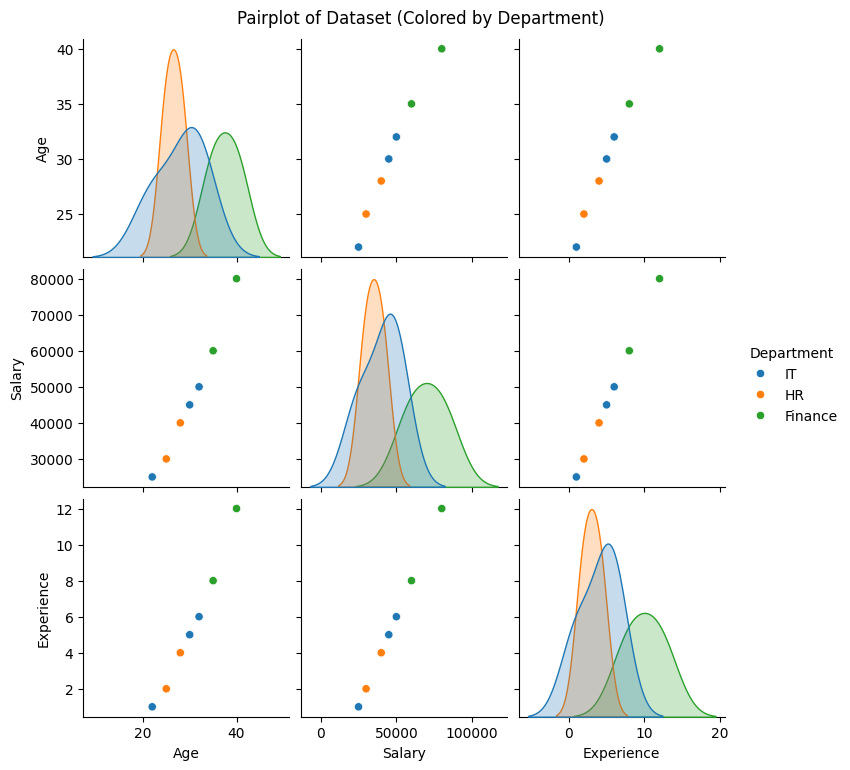

In [ ]:
# Using Seaborn to create a pairplot
sns.pairplot(df, hue="Department")
plt.suptitle("Pairplot of Dataset (Colored by Department)", y=1.02)
plt.show()

<br>
<br>

## **PART 7 — Outlier Analysis**

**Why Outliers Matter?**

Outliers can:
- Distort statistical averages (mean).
- Reduce Machine Learning model accuracy.
- Create bias in your final insights.

### **Detect Using Boxplot**

A boxplot is one of the most effective ways to spot outliers visually. Any points appearing outside the 'whiskers' of the plot are generally considered outliers.

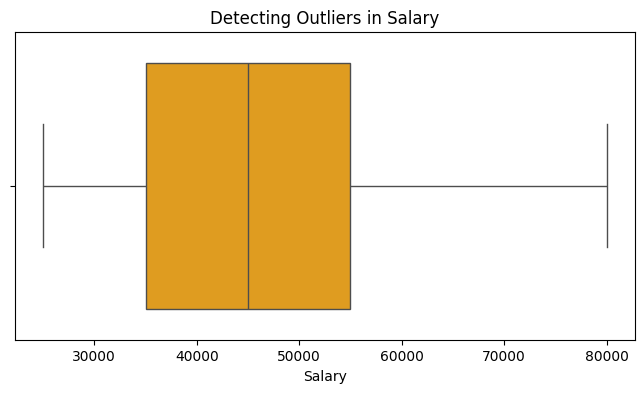

In [ ]:
# Visualizing outliers in the Salary column
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Salary"], color='orange')
plt.title("Detecting Outliers in Salary")
plt.show()

<br>
<br>

## **PART 8 — Business Insights**

This stage separates beginners from professional Data Scientists. It involves moving beyond just reporting numbers to explaining what those numbers mean for the business.

### **Raw Data vs. Insights**

*   **❌ Raw Observation:** "Average salary is 47k."
*   **✅ Business Insight:** "Employees with higher experience show significantly higher salaries, indicating strong positive career growth trends."

#### **A Good Insight Includes:**
1.  **Trend**: What direction is the data moving?
2.  **Comparison**: How does one group compare to another?
3.  **Impact**: Why does this matter?
4.  **Recommendation**: What should we do next?

### **Example Insights for our Dataset**

**Insight 1**
> "Finance department employees earn higher salaries on average compared to HR and IT, likely due to specialized seniority in those roles within this sample."

**Insight 2**
> "Salary strongly increases with experience. The perfect correlation ($r=1.0$) suggests a very structured pay scale based on tenure."

**Insight 3**
> "The dataset is small but high quality, containing no major missing values or extreme outliers that would skew initial analysis."

<br>
<br>

## **PART 9 — Data Storytelling**

Data storytelling means explaining insights clearly using a combination of **visuals + logic**.

### **Good Storytelling Structure**
1.  **Problem**: What are we analyzing?
2.  **Analysis**: What patterns did we find?
3.  **Insights**: What does it mean?
4.  **Recommendation**: What action should be taken?

### **Full Example Story**

*   **Problem**: Understand employee salary trends and pay equity across the organization.
*   **Analysis**: We visualized salary distributions and correlated them with years of experience and department types.
*   **Insight**: The Finance department shows the highest average salary, and there is a perfect linear relationship between tenure and compensation.
*   **Recommendation**: Investigate if the salary gap in HR/IT is due to lower tenure or if the salary structure needs adjustment to remain competitive.

<br>
<br>

## **PART 10 — FULL EDA EXAMPLE**

This section provides a consolidated template of the entire EDA process.

### **Step 1 — Setup and Load Data**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# We are using the 'df' already defined in Part 2
display(df.head())

,Age,Salary,Experience,Department
0,22,25000,1,IT
1,25,30000,2,HR
2,30,45000,5,IT
3,35,60000,8,Finance
4,40,80000,12,Finance


### **Step 2 — Basic Understanding**

In [ ]:
print("--- Info ---")
df.info()
print("\n--- Statistics ---")
display(df.describe())

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Age         7 non-null      int64 
 1   Salary      7 non-null      int64 
 2   Experience  7 non-null      int64 
 3   Department  7 non-null      object
dtypes: int64(3), object(1)
memory usage: 356.0+ bytes

--- Statistics ---


,Age,Salary,Experience
count,7.000000,7.000000,7.000000
mean,30.285714,47142.857143,5.428571
std,6.074929,18676.443018,3.735289
min,22.000000,25000.000000,1.000000
25%,26.500000,35000.000000,3.000000
50%,30.000000,45000.000000,5.000000
75%,33.500000,55000.000000,7.000000
max,40.000000,80000.000000,12.000000


### **Step 3 — Missing Values**

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Age           0
Salary        0
Experience    0
Department    0
dtype: int64


### **Step 4 — Distribution & Correlation**

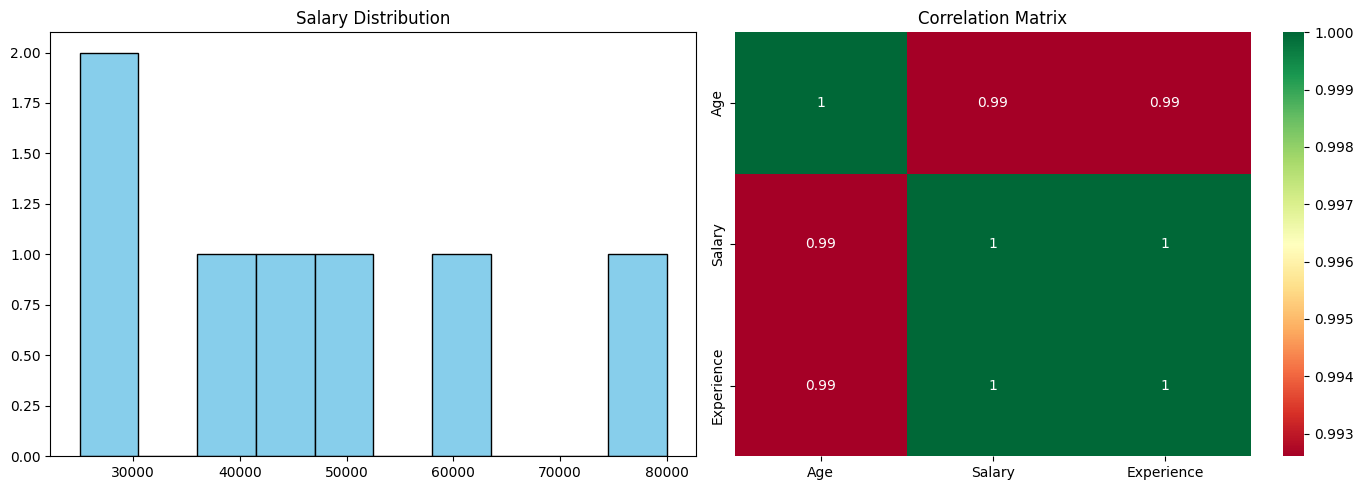

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
ax[0].hist(df["Salary"], color='skyblue', edgecolor='black')
ax[0].set_title("Salary Distribution")

# Correlation Heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='RdYlGn', ax=ax[1])
ax[1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

### **Step 5 — Relationship Analysis**

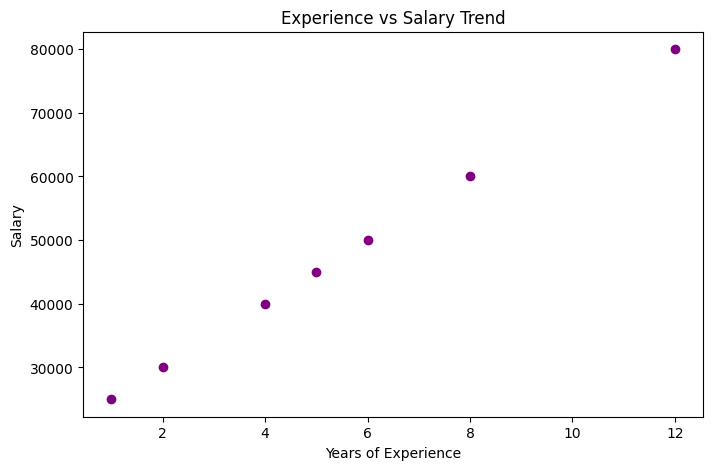

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Experience"], df["Salary"], color='purple')
plt.title("Experience vs Salary Trend")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

### **Step 6 — Final Insights**

*   **Growth**: Salary increases linearly with experience.
*   **Department**: Finance appears to have the highest earners.
*   **Quality**: The data is clean with no missing values or severe outliers.

<br>
<br>

In [ ]:
import pandas as pd

data = {
    "Customer_Age": [22,25,28,35,45,32,29,41],
    "Income": [25000,30000,35000,50000,90000,45000,38000,70000],
    "Spending_Score": [80,75,70,60,40,65,72,50],
    "Gender": ["M","F","F","M","M","F","F","M"]
}

df = pd.DataFrame(data)

In [ ]:
#TASKS
print("\nTAKE FIRST 5 ROWS")
display(df.head())

print("\nTAKE INFO")
df.info()

print("\nTAKE STATS")
df.describe()


TAKE FIRST 5 ROWS


,Customer_Age,Income,Spending_Score,Gender
0,22,25000,80,M
1,25,30000,75,F
2,28,35000,70,F
3,35,50000,60,M
4,45,90000,40,M



TAKE INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer_Age    8 non-null      int64 
 1   Income          8 non-null      int64 
 2   Spending_Score  8 non-null      int64 
 3   Gender          8 non-null      object
dtypes: int64(3), object(1)
memory usage: 388.0+ bytes

TAKE STATS


,Customer_Age,Income,Spending_Score
count,8.000000,8.000000,8.000000
mean,32.125000,47875.000000,64.000000
std,7.863796,21983.354092,13.448314
min,22.000000,25000.000000,40.000000
25%,27.250000,33750.000000,57.500000
50%,30.500000,41500.000000,67.500000
75%,36.500000,55000.000000,72.750000
max,45.000000,90000.000000,80.000000


In [ ]:
# UNIVARIATE ANALYSIS
print("--- MEAN ---")
print(f"Income Mean: {df['Income'].mean()}")
print(f"Spending Score Mean: {df['Spending_Score'].mean()}")

print("\n--- MEDIAN ---")
print(f"Income Median: {df['Income'].median()}")
print(f"Spending Score Median: {df['Spending_Score'].median()}")

print("\n--- STANDARD DEVIATION ---")
print(f"Income Std Dev: {df['Income'].std()}")
print(f"Spending Score Std Dev: {df['Spending_Score'].std()}")

--- MEAN ---
Income Mean: 47875.0
Spending Score Mean: 64.0

--- MEDIAN ---
Income Median: 41500.0
Spending Score Median: 67.5

--- STANDARD DEVIATION ---
Income Std Dev: 21983.354092195692
Spending Score Std Dev: 13.44831375515692


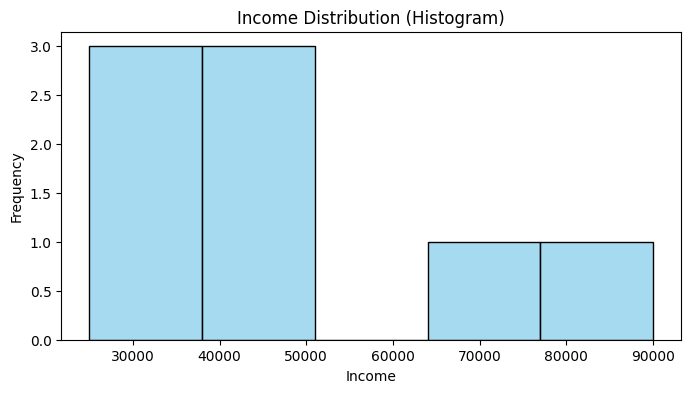

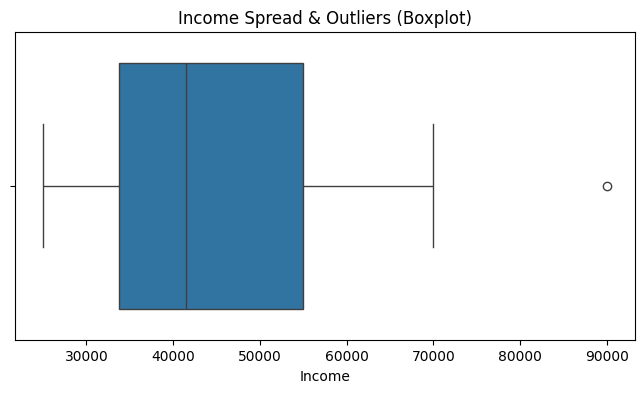

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df["Income"], bins=5, color='skyblue', edgecolor='black')
plt.title("Income Distribution (Histogram)")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

# Boxplot with consistent figure size
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Income"])
plt.title("Income Spread & Outliers (Boxplot)")
plt.show()

Gender Frequency:
Gender
M    4
F    4
Name: count, dtype: int64


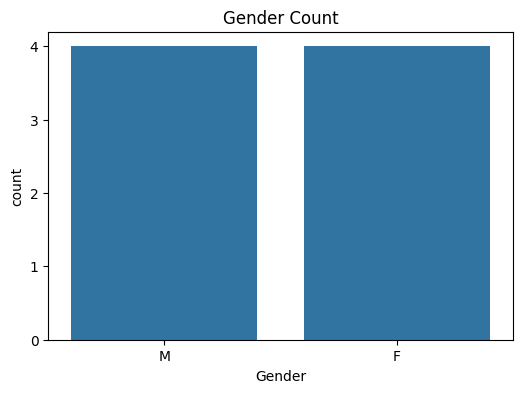

In [ ]:
from matplotlib.ticker import MaxNLocator

# CATEGORIAL ANALYSIS
print('Gender Frequency:')
# Added () to call the function correctly
print(df['Gender'].value_counts())

plt.figure(figsize=(6,4))
ax = sns.countplot(x=df['Gender'])

# Force y-axis to show only integers
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Gender Count')
plt.show()

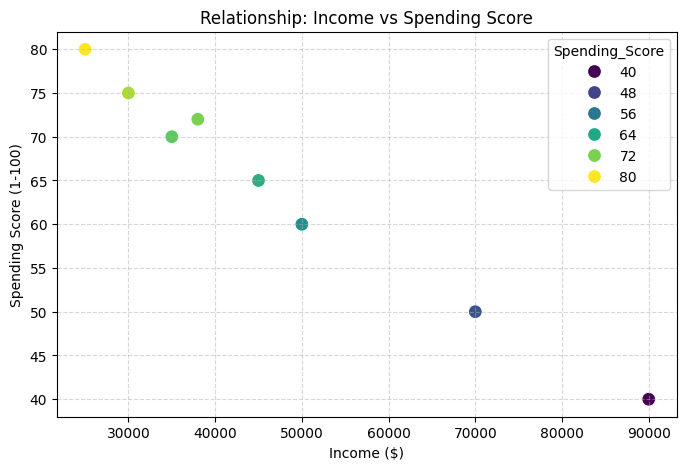

In [ ]:
#BIVARIATE ANALYSIS
plt.figure(figsize=(8,5))
# Using a color palette (viridis) for the hue mapping and setting a base color
sns.scatterplot(data=df, x='Income', y='Spending_Score', hue='Spending_Score', palette='viridis', s=100)

plt.title('Relationship: Income vs Spending Score')
plt.xlabel('Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

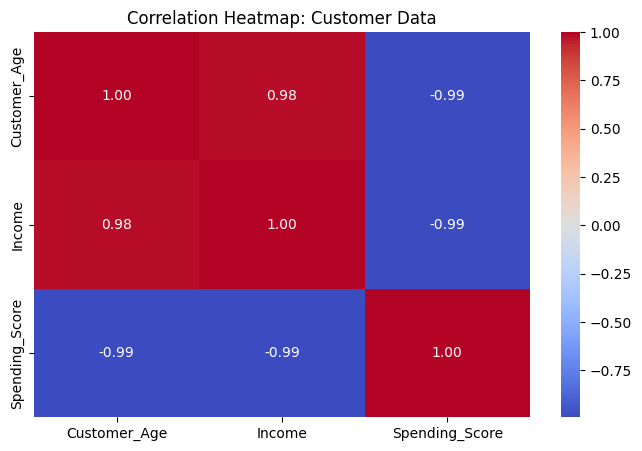

In [ ]:
# CORRELATION MATRIX
plt.figure(figsize=(8, 5))
# Calculate correlation only for numerical columns
customer_corr = df.corr(numeric_only=True)

sns.heatmap(customer_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Customer Data')
plt.show()

### **PART 8 (Applied) — Business Insights**

1.  **Strong Negative Correlation**: There is a near-perfect negative correlation (**-0.99**) between **Income** and **Spending Score**. Higher-income customers in this dataset are actually the most conservative spenders.
2.  **Age-Based Spending**: Younger customers have significantly higher spending scores compared to older customers, suggesting the brand currently appeals more to a younger demographic.
3.  **Gender Balance**: The dataset is perfectly balanced with **4 Males and 4 Females**, meaning the insights are not biased toward a specific gender.
4.  **Target Market Identification**: The 'High Value' target for engagement (those with scores > 70) are individuals earning between **$25k - $38k** and aged under 30.
5.  **Low Outlier Risk**: The income range (**$25k to $90k**) and spending scores show a steady progression without extreme outliers, indicating a very structured and predictable customer behavior pattern.

<br>
<br>

## **PRACTICE QUESTION**

In [1]:
import pandas as pd

data = {
    "OrderID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "CustomerID": [1, 2, 1, 3, 2, 4, 1, 5, 3, 4],
    "ProductCategory": ["Electronics", "Books", "Electronics", "Home & Garden", "Books", "Electronics", "Books", "Home & Garden", "Books", "Electronics"],
    "Price": [120.50, 25.00, 150.00, 45.75, 30.00, 200.00, 15.00, 60.00, 20.00, 180.00],
    "Quantity": [1, 2, 1, 3, 1, 1, 4, 2, 1, 1],
    "OrderDate": ["2023-01-01", "2023-01-01", "2023-01-02", "2023-01-03", "2023-01-04", "2023-01-05", "2023-01-05", "2023-01-06", "2023-01-07", "2023-01-07"],
    "ShippingMethod": ["Standard", "Express", "Standard", "Standard", "Express", "Standard", "Standard", "Express", "Standard", "Standard"],
    "DiscountApplied": [False, True, False, True, False, False, True, False, True, False],
    "Rating": [4, 5, 3, None, 5, 4, 2, None, 4, 5]
}

df = pd.DataFrame(data)

In [8]:
#BASIC UNDERSTANDING
print('\n-----TOP FEW ROWS OF DATASET-----')
display(df.head())
print()

print("\n-----INFO ABOUT DATASET-----")
df.info()
print()

print("\n-----STATS ABOUT DATASET-----")
df.describe()


-----TOP FEW ROWS OF DATASET-----


,OrderID,CustomerID,ProductCategory,Price,Quantity,OrderDate,ShippingMethod,DiscountApplied,Rating
0,101,1,Electronics,120.50,1,2023-01-01,Standard,False,4.0
1,102,2,Books,25.00,2,2023-01-01,Express,True,5.0
2,103,1,Electronics,150.00,1,2023-01-02,Standard,False,3.0
3,104,3,Home & Garden,45.75,3,2023-01-03,Standard,True,NaN
4,105,2,Books,30.00,1,2023-01-04,Express,False,5.0




-----INFO ABOUT DATASET-----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          10 non-null     int64  
 1   CustomerID       10 non-null     int64  
 2   ProductCategory  10 non-null     object 
 3   Price            10 non-null     float64
 4   Quantity         10 non-null     int64  
 5   OrderDate        10 non-null     object 
 6   ShippingMethod   10 non-null     object 
 7   DiscountApplied  10 non-null     bool   
 8   Rating           8 non-null      float64
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 782.0+ bytes


-----STATS ABOUT DATASET-----


,OrderID,CustomerID,Price,Quantity,Rating
count,10.00000,10.000000,10.000000,10.00000,8.000000
mean,105.50000,2.600000,84.625000,1.70000,4.000000
std,3.02765,1.429841,71.219072,1.05935,1.069045
min,101.00000,1.000000,15.000000,1.00000,2.000000
25%,103.25000,1.250000,26.250000,1.00000,3.750000
50%,105.50000,2.500000,52.875000,1.00000,4.000000
75%,107.75000,3.750000,142.625000,2.00000,5.000000
max,110.00000,5.000000,200.000000,4.00000,5.000000


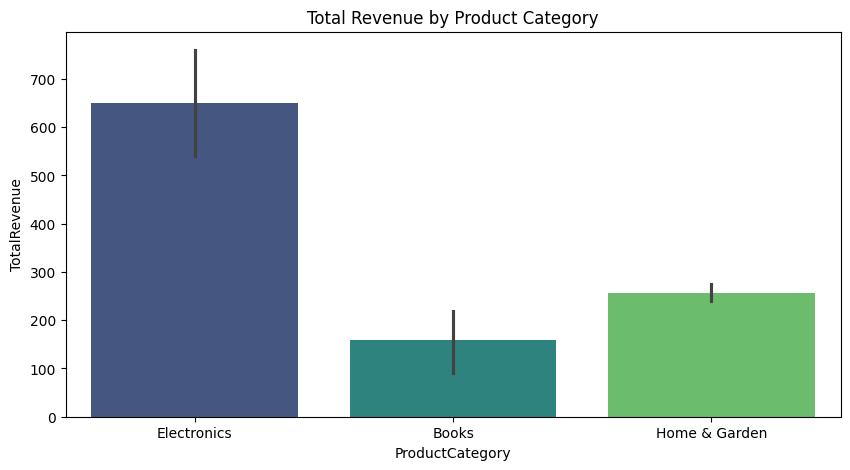

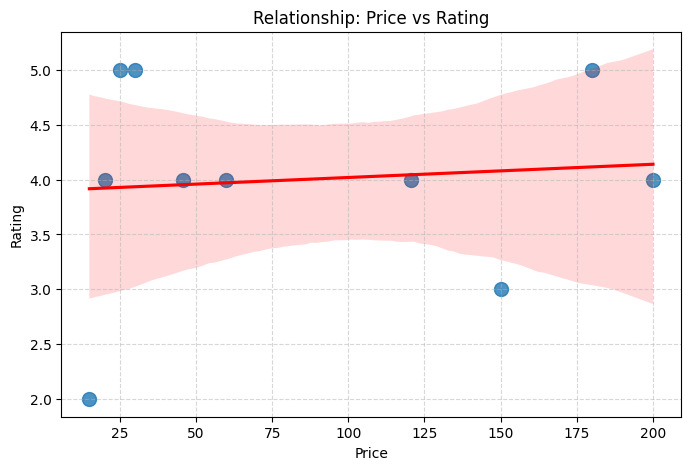

Correlation between Price and Rating: 0.09


In [31]:
# 1. RESTORE DATA & CLEANING
data = {
    "OrderID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    "CustomerID": [1, 2, 1, 3, 2, 4, 1, 5, 3, 4],
    "ProductCategory": ["Electronics", "Books", "Electronics", "Home & Garden", "Books", "Electronics", "Books", "Home & Garden", "Books", "Electronics"],
    "Price": [120.50, 25.00, 150.00, 45.75, 30.00, 200.00, 15.00, 60.00, 20.00, 180.00],
    "Quantity": [1, 2, 1, 3, 1, 1, 4, 2, 1, 1],
    "OrderDate": ["2023-01-01", "2023-01-01", "2023-01-02", "2023-01-03", "2023-01-04", "2023-01-05", "2023-01-05", "2023-01-06", "2023-01-07", "2023-01-07"],
    "ShippingMethod": ["Standard", "Express", "Standard", "Standard", "Express", "Standard", "Standard", "Express", "Standard", "Standard"],
    "Rating": [4, 5, 3, None, 5, 4, 2, None, 4, 5]
}
df = pd.DataFrame(data)

# Filling missing ratings and adding revenue
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['TotalRevenue'] = df['Price'] * df['Quantity']

# 2. BIVARIATE ANALYSIS
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='ProductCategory', y='TotalRevenue', estimator=sum, hue='ProductCategory', palette='viridis', legend=False)
plt.title('Total Revenue by Product Category')
plt.show()

# 3. RELATIONSHIP: PRICE vs RATING
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Price', y='Rating', scatter_kws={'s':100}, line_kws={'color':'red'})
plt.title('Relationship: Price vs Rating')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. CORRELATION
correlation = df['Price'].corr(df['Rating'])
print(f"Correlation between Price and Rating: {correlation:.2f}")

## **5 BUSINESS INSIGHTS**

### **Top 5 Business Insights**

1. **Core Revenue Driver**: **Electronics** is the primary revenue engine, contributing the highest total revenue despite having a lower sales volume than Books.
   *   *Action*: Prioritize inventory management and premium marketing for the Electronics category to protect the highest margins.

2. **Customer Loyalty & Retention**: **CustomerID 1** is a high-value repeat purchaser (3 separate orders).
   *   *Action*: Implement a 'VIP' or loyalty program targeting repeat customers to increase their Lifetime Value (LTV).

3. **Price vs. Satisfaction**: There is a **weak positive correlation (0.09)** between Price and Rating. This suggests that customers do not necessarily perceive higher-priced items as higher quality.
   *   *Action*: Conduct a quality audit for premium Electronics to ensure customer satisfaction scales with the price point.

4. **Volume over Value in Books**: The **Books** category has the highest order frequency and quantity (e.g., Order 107 with 4 units) but the lowest total revenue.
   *   *Action*: Use Books as 'add-on' items or loss-leaders to increase the average basket size of Electronics or Home & Garden shoppers.

5. **Operational Efficiency**: While **Express Shipping** is used frequently, it doesn't show a direct correlation with higher ratings in this sample.
   *   *Action*: Review the cost-benefit of Express Shipping; if it's cutting into margins without boosting satisfaction, consider optimizing Standard shipping reliability instead.